Dataset V1: /content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1
Baseline output: /content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Classical_Baselines
Dataset shape: (314, 7)

Columns:
['image_id', 'source_archive', 'gen', 'input', 'target', 'sample_id', 'split']

Total test samples: 48


,image_id,source_archive,gen,input,target,sample_id,split
266,118,epoch_0096,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,epoch_0096_118,test
267,24,epoch_0096,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,epoch_0096_24,test
268,91,extracted_dataset,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,extracted_dataset_91,test
269,107,epoch_0096,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,epoch_0096_107,test
270,67,epoch_0096,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,epoch_0096_67,test



Running classical enhancement methods...



100%|██████████| 48/48 [00:04<00:00, 10.24it/s]


Individual results saved:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Classical_Baselines/all_baseline_results.csv


...

CLASSICAL BASELINE COMPARISON


,method,PSNR,SSIM,Edge_Preservation
0,CLAHE,13.888109,0.613580,0.025002
1,Gamma,13.893641,0.654586,0.006676
2,GrayWorld,13.327233,0.653937,0.008210


BASELINE COMPARISON WITH RANKS


,method,PSNR,SSIM,Edge_Preservation,PSNR_Rank,SSIM_Rank,Edge_Rank,Average_Rank
1,Gamma,13.893641,0.654586,0.006676,1.0,1.0,3.0,1.666667
0,CLAHE,13.888109,0.613580,0.025002,2.0,3.0,1.0,2.000000
2,GrayWorld,13.327233,0.653937,0.008210,3.0,2.0,2.0,2.333333



Classical reference among tested methods:
Gamma


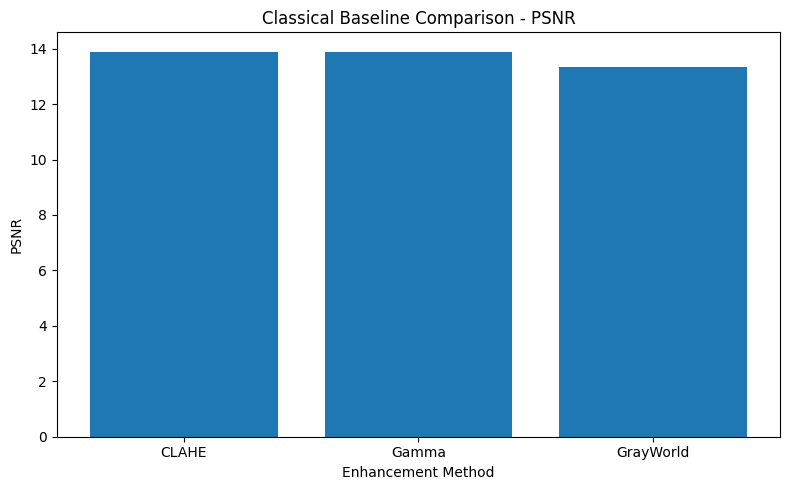

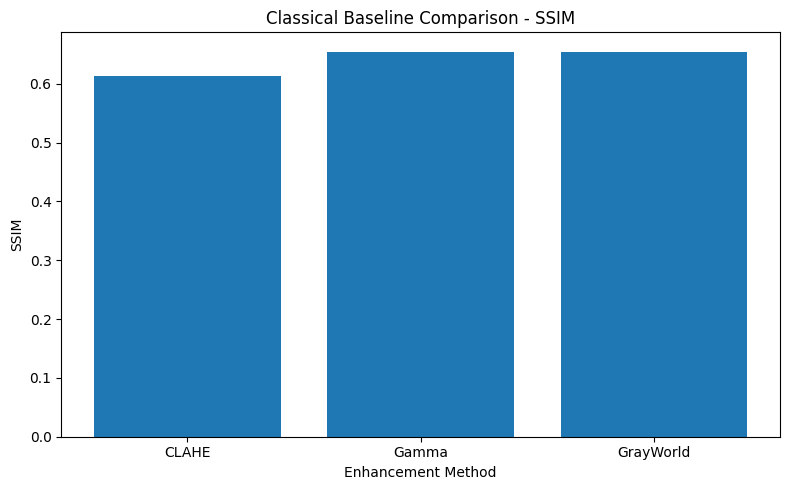

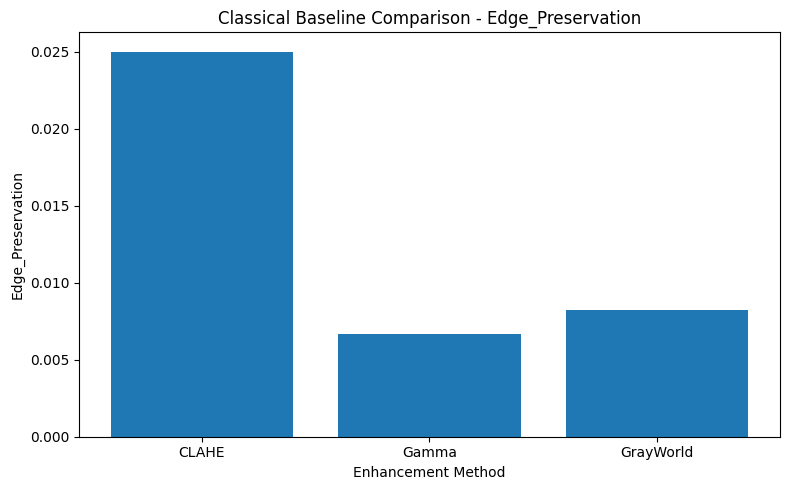

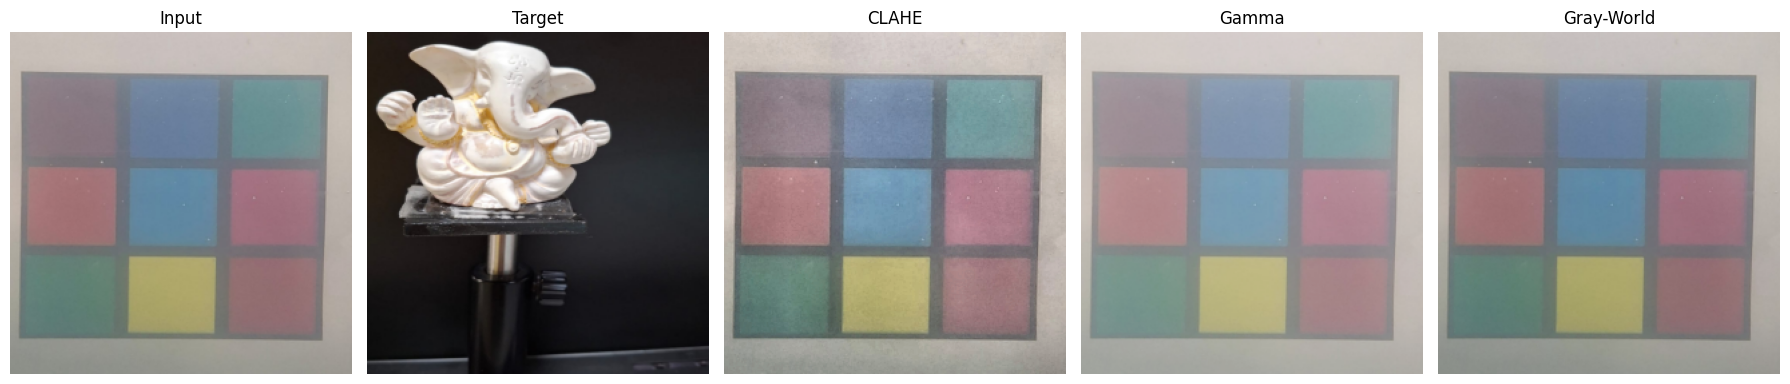

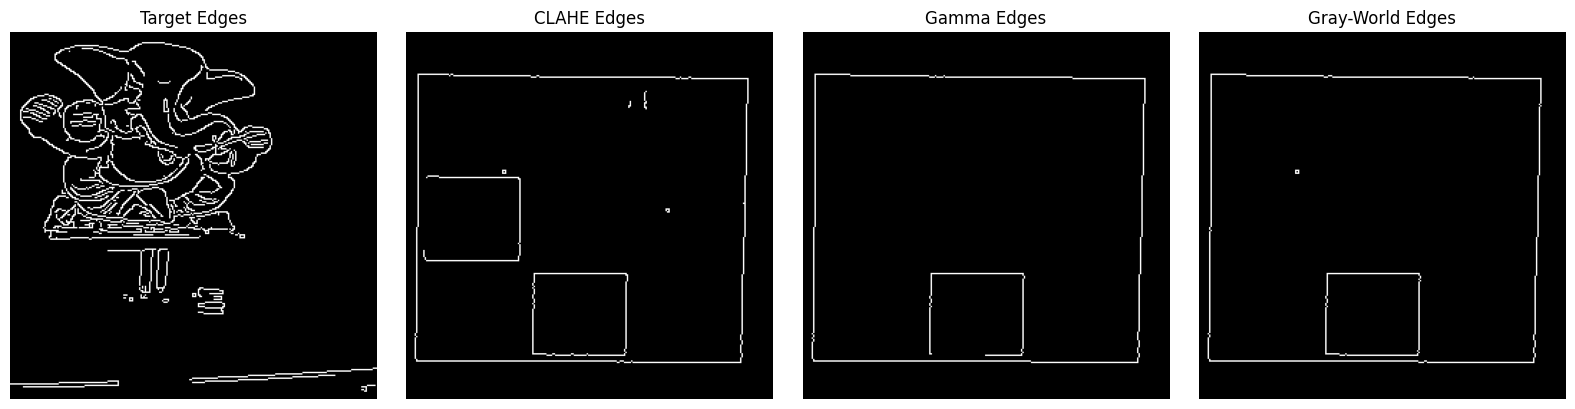



CLASSICAL BASELINE STAGE COMPLETE

Methods:
 - CLAHE
 - Gamma
 - GrayWorld

Selected classical reference:
 >>> Gamma

Results saved in:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Classical_Baselines


In [10]:

import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity


PROJECT_DIR = Path(
    "/content/drive/MyDrive/Underwater-Image-Data-set-main"
)

V1_DIR = PROJECT_DIR / "Dataset_V1"

BASELINE_DIR = V1_DIR / "Classical_Baselines"

BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset V1:", V1_DIR)
print("Baseline output:", BASELINE_DIR)



split_file = V1_DIR / "Dataset_V1_splits.csv"

splits = pd.read_csv(split_file)

print("Dataset shape:", splits.shape)

print("\nColumns:")
print(splits.columns.tolist())


test_df = splits[
    splits["split"] == "test"
].copy()

print("\nTotal test samples:", len(test_df))

display(test_df.head())

def read_image(path):

    img = cv2.imread(str(path))

    if img is None:
        raise ValueError(
            f"Could not read image: {path}"
        )

    # OpenCV uses BGR
    # Convert to RGB
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    return img


# BASELINE 1 — CLAHE

def clahe_enhancement(image):

    # Convert RGB -> LAB
    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([
        l_enhanced,
        a,
        b
    ])

    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced

# BASELINE 2 — GAMMA CORRECTION


def gamma_correction(
    image,
    gamma=1.3
):

    table = np.array([
        ((i / 255.0) ** (1.0 / gamma)) * 255
        for i in range(256)
    ]).astype(np.uint8)

    enhanced = cv2.LUT(
        image,
        table
    )

    return enhanced

#BASELINE 3 — GRAY-WORLD WHITE BALANCE

def gray_world_white_balance(image):

    image_float = image.astype(
        np.float32
    )

    mean_r = np.mean(
        image_float[:, :, 0]
    )

    mean_g = np.mean(
        image_float[:, :, 1]
    )

    mean_b = np.mean(
        image_float[:, :, 2]
    )

    mean_gray = (
        mean_r +
        mean_g +
        mean_b
    ) / 3

    image_float[:, :, 0] *= (
        mean_gray / (mean_r + 1e-8)
    )

    image_float[:, :, 1] *= (
        mean_gray / (mean_g + 1e-8)
    )

    image_float[:, :, 2] *= (
        mean_gray / (mean_b + 1e-8)
    )

    image_float = np.clip(
        image_float,
        0,
        255
    )

    return image_float.astype(
        np.uint8
    )

#EDGE EXTRACTION

def extract_edges(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    edges = cv2.Canny(
        gray,
        100,
        200
    )

    return edges

#EDGE PRESERVATION

def edge_preservation_score(
    reference,
    enhanced
):

    reference_edges = extract_edges(
        reference
    )

    enhanced_edges = extract_edges(
        enhanced
    )

    reference_mask = (
        reference_edges > 0
    )

    enhanced_mask = (
        enhanced_edges > 0
    )

    overlap = np.logical_and(
        reference_mask,
        enhanced_mask
    )

    reference_edge_count = np.sum(
        reference_mask
    )

    if reference_edge_count == 0:
        return 0.0

    score = (
        np.sum(overlap)
        / reference_edge_count
    )

    return float(score)

# IMAGE QUALITY METRICS

def calculate_metrics(
    reference,
    enhanced
):

    # Make sure both images have
    # the same dimensions
    if reference.shape != enhanced.shape:

        enhanced = cv2.resize(
            enhanced,
            (
                reference.shape[1],
                reference.shape[0]
            )
        )

    psnr = peak_signal_noise_ratio(
        reference,
        enhanced,
        data_range=255
    )

    ssim = structural_similarity(
        reference,
        enhanced,
        channel_axis=2,
        data_range=255
    )

    edge_score = edge_preservation_score(
        reference,
        enhanced
    )

    return psnr, ssim, edge_score

#CREATE OUTPUT FOLDERS


methods = [
    "CLAHE",
    "Gamma",
    "GrayWorld"
]

for method in methods:

    (
        BASELINE_DIR / method
    ).mkdir(
        parents=True,
        exist_ok=True
    )


#RUN BASELINES


results = []

print("\nRunning classical enhancement methods...\n")

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df)
):

    # IMPORTANT:
    # Your CSV uses "input" and "target"
    input_path = row["input"]
    target_path = row["target"]

    input_img = read_image(
        input_path
    )

    target_img = read_image(
        target_path
    )

    # CLAHE


    clahe_img = clahe_enhancement(
        input_img
    )

    psnr, ssim, edge = calculate_metrics(
        target_img,
        clahe_img
    )

    output_file = (
        BASELINE_DIR
        / "CLAHE"
        / f"{row['sample_id']}_CLAHE.png"
    )

    cv2.imwrite(
        str(output_file),
        cv2.cvtColor(
            clahe_img,
            cv2.COLOR_RGB2BGR
        )
    )

    results.append({
        "sample_id": row["sample_id"],
        "method": "CLAHE",
        "PSNR": psnr,
        "SSIM": ssim,
        "Edge_Preservation": edge
    })

    # GAMMA


    gamma_img = gamma_correction(
        input_img,
        gamma=1.3
    )

    psnr, ssim, edge = calculate_metrics(
        target_img,
        gamma_img
    )

    output_file = (
        BASELINE_DIR
        / "Gamma"
        / f"{row['sample_id']}_Gamma.png"
    )

    cv2.imwrite(
        str(output_file),
        cv2.cvtColor(
            gamma_img,
            cv2.COLOR_RGB2BGR
        )
    )

    results.append({
        "sample_id": row["sample_id"],
        "method": "Gamma",
        "PSNR": psnr,
        "SSIM": ssim,
        "Edge_Preservation": edge
    })


    # GRAY-WORLD


    grayworld_img = (
        gray_world_white_balance(
            input_img
        )
    )

    psnr, ssim, edge = calculate_metrics(
        target_img,
        grayworld_img
    )

    output_file = (
        BASELINE_DIR
        / "GrayWorld"
        / f"{row['sample_id']}_GrayWorld.png"
    )

    cv2.imwrite(
        str(output_file),
        cv2.cvtColor(
            grayworld_img,
            cv2.COLOR_RGB2BGR
        )
    )

    results.append({
        "sample_id": row["sample_id"],
        "method": "GrayWorld",
        "PSNR": psnr,
        "SSIM": ssim,
        "Edge_Preservation": edge
    })
#SAVE ALL RESULTS


results_df = pd.DataFrame(
    results
)

results_file = (
    BASELINE_DIR /
    "all_baseline_results.csv"
)

results_df.to_csv(
    results_file,
    index=False
)

print("\nIndividual results saved:")
print(results_file)

display(results_df.head())


# COMPARE BASELINES

comparison = (
    results_df
    .groupby("method")[
        [
            "PSNR",
            "SSIM",
            "Edge_Preservation"
        ]
    ]
    .mean()
    .reset_index()
)
print("CLASSICAL BASELINE COMPARISON")

display(comparison)


# Save comparison
comparison.to_csv(
    BASELINE_DIR /
    "baseline_comparison.csv",
    index=False
)

#RANK METHODS


ranked = comparison.copy()

ranked["PSNR_Rank"] = (
    ranked["PSNR"]
    .rank(ascending=False)
)

ranked["SSIM_Rank"] = (
    ranked["SSIM"]
    .rank(ascending=False)
)

ranked["Edge_Rank"] = (
    ranked["Edge_Preservation"]
    .rank(ascending=False)
)

ranked["Average_Rank"] = (
    ranked[
        [
            "PSNR_Rank",
            "SSIM_Rank",
            "Edge_Rank"
        ]
    ].mean(axis=1)
)

ranked = ranked.sort_values(
    "Average_Rank"
)

print("BASELINE COMPARISON WITH RANKS")

display(ranked)

# SELECT CLASSICAL REFERENCE


strongest_method = (
    ranked.iloc[0]["method"]
)

print("\nClassical reference among tested methods:")
print(strongest_method)

#SAVE FINAL REPORT

report = {
    "methods_tested": methods,

    "metrics": [
        "PSNR",
        "SSIM",
        "Edge_Preservation"
    ],

    "selection_method":
        "Average rank across PSNR, SSIM and Edge Preservation",

    "selected_reference":
        strongest_method,

    "evaluation_split":
        "Dataset V1 test split",

    "note":
        "The selected method is the strongest among the tested classical methods on this Dataset V1 test split."
}

with open(
    BASELINE_DIR /
    "Dataset_V1_classical_baseline_report.json",
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=4
    )

#METRIC PLOTS

for metric in [
    "PSNR",
    "SSIM",
    "Edge_Preservation"
]:

    plt.figure(figsize=(8, 5))

    plt.bar(
        comparison["method"],
        comparison[metric]
    )

    plt.xlabel(
        "Enhancement Method"
    )

    plt.ylabel(metric)

    plt.title(
        f"Classical Baseline Comparison - {metric}"
    )

    plt.tight_layout()

    plt.savefig(
        BASELINE_DIR /
        f"{metric}_comparison.png",
        dpi=300
    )

    plt.show()

#VISUAL COMPARISON

sample = test_df.iloc[0]

input_img = read_image(
    sample["input"]
)

target_img = read_image(
    sample["target"]
)

clahe_img = clahe_enhancement(
    input_img
)

gamma_img = gamma_correction(
    input_img,
    gamma=1.3
)

grayworld_img = (
    gray_world_white_balance(
        input_img
    )
)

images = [
    input_img,
    target_img,
    clahe_img,
    gamma_img,
    grayworld_img
]

titles = [
    "Input",
    "Target",
    "CLAHE",
    "Gamma",
    "Gray-World"
]

plt.figure(figsize=(18, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(images[i])

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    BASELINE_DIR /
    "classical_baseline_visual_comparison.png",
    dpi=300
)

plt.show()

# EDGE COMPARISON

edge_images = [
    extract_edges(target_img),
    extract_edges(clahe_img),
    extract_edges(gamma_img),
    extract_edges(grayworld_img)
]

edge_titles = [
    "Target Edges",
    "CLAHE Edges",
    "Gamma Edges",
    "Gray-World Edges"
]

plt.figure(figsize=(16, 4))

for i in range(4):

    plt.subplot(1, 4, i + 1)

    plt.imshow(
        edge_images[i],
        cmap="gray"
    )

    plt.title(
        edge_titles[i]
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    BASELINE_DIR /
    "edge_comparison.png",
    dpi=300
)

plt.show()

# FINAL OUTPUT

print("\n")
print("=" * 60)
print("CLASSICAL BASELINE STAGE COMPLETE")
print("=" * 60)

print("\nMethods:")
for method in methods:
    print(" -", method)

print("\nSelected classical reference:")
print(" >>>", strongest_method)

print("\nResults saved in:")
print(BASELINE_DIR)

In [8]:
print("Split file:", split_file)
print("\nColumns in your CSV:")
print(splits.columns.tolist())

print("\nFirst 3 rows:")
display(splits.head(3))

Split file: /content/drive/MyDrive/Underwater-Image-Data-set-main/Dataset_V1/Dataset_V1_splits.csv

Columns in your CSV:
['image_id', 'source_archive', 'gen', 'input', 'target', 'sample_id', 'split']

First 3 rows:


,image_id,source_archive,gen,input,target,sample_id,split
0,63,epoch_0096,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,epoch_0096_63,train
1,10,epoch_0096,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,epoch_0096_10,train
2,158,extracted_dataset,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,/content/drive/MyDrive/Underwater-Image-Data-s...,extracted_dataset_158,train
